In [1]:
import numpy as np
import random
import math
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import log_loss

#创建用户类
class Client():
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.w_cur=[]
        self.number=len(y)

def sigmoid(x):
    return 1/(1 +np.exp(-x))


def RMSprop(sk,gk):
    sk=sk*0.9+0.1*(gk*gk)
    return 0.01/np.sqrt(sk+np.exp(-8))

        
def multdata(alpha,beta,dim,num):
    num=num*2
    uk=np.squeeze(np.random.normal(loc =0 , scale= alpha ,size = (1,dim)))
    cov_1=np.identity(dim)
    wk=np.squeeze(np.random.multivariate_normal(uk, cov_1, (1,), 'raise'))
    cov_1=np.identity(dim)
    Bk=np.squeeze(np.random.normal(loc =0 , scale= beta,size = (1,dim)))
    vk=np.squeeze(np.random.multivariate_normal(Bk, cov_1, (1,), 'raise'))
    cov_x=np.identity(dim)
    xk= np.random.multivariate_normal(vk,cov_x, (num,), 'raise')
    
    yk=np.zeros((num,1))
    for i in range(0,num):
          if(sigmoid(np.dot(xk[i],np.transpose(wk)))>=0.5):
                yk[i]=1
    return xk,yk

def iid(wk,beta,dim,num,vk):
    cov_x=np.identity(dim)
    xk= np.random.multivariate_normal(vk,cov_x, (num*2,), 'raise')
    
    yk=np.zeros((num*2,1))
    for i in range(0,num*2):
          if(sigmoid(np.dot(xk[i],np.transpose(wk)))>=0.5):
                yk[i]=1
    return xk,yk

def create_wk(v,dim):
    uk=np.squeeze(np.random.normal(loc =0 , scale= v**2 ,size = (1,dim)))
    cov_1=np.identity(dim)
    wk=np.squeeze(np.random.multivariate_normal(uk, cov_1, (1,), 'raise'))
    return wk

def L1Norm(theta,lam=1):
    return  np.dot(np.transpose(np.abs(theta)), np.ones((theta.size,1))) * lam
 
def L1NormPartial(theta,lam=1):
    return np.sign(theta) * lam

In [2]:
def loss_funtion_avg(data,Class, weights):
    loss = 0.0
    for i in range(0,len(data)):
        y_pred = np.squeeze(sigmoid(data[i].dot(weights)))
        if y_pred>1-1e-10 or y_pred<1e-10:
            continue
        loss += -Class[i,0] * np.log(y_pred) - (1 - Class[i,0]) * np.log(1 - y_pred)
    return loss

def loss_funtion_prox(data,Class, weights,w0,miu):
    loss = 0.0
    for i in range(0,len(data)):
        y_pred = np.squeeze(sigmoid(data[i].dot(weights)))
        if y_pred>1-1e-5 or y_pred<1e-5:
            continue
        loss += -Class[i,0] * np.log(y_pred) - (1 - Class[i,0]) * np.log(1 - y_pred)
    loss+=miu*0.5*(np.linalg.norm(w0-weights))**2

    return loss

def loss_funtion_prior(data,Class, weights,w0,yita,lam=1):
    loss = 0.0
    for i in range(0,len(data)):
        y_pred = np.squeeze(sigmoid(data[i].dot(weights)))
        if y_pred>1-1e-5 or y_pred<1e-5:
            continue
        loss += -Class[i,0] * np.log(y_pred) - (1 - Class[i,0]) * np.log(1 - y_pred)
    loss+=L1Norm(weights,lam/(1+yita))
    return loss

In [3]:
def grad_descent_global(data, Class,w0,batchsize):
    data_num=len(Class)
    batch_num=data_num//batchsize 
    weights = w0
    weights=np.mat(weights)
    data=np.mat(data)
    Class=np.mat(Class)
    sk=0
    maxstep=20
    #初始化training_loss
    new_loss = loss_funtion_avg(data,Class, weights)
    for i in range(maxstep):
        row_indice=np.random.permutation(data_num)
        loss = new_loss
        for k in range(batch_num):
            # 随机选择
            s = row_indice[k*batchsize:(k+1)*batchsize]
                # 得到该样本的特征向量和标记
            xi = data[s]
            yi=Class[s]
            output = sigmoid(xi * weights)
            gk = xi.T *(-yi+output)/batchsize
            #+L1NormPartial(weights,1)
            sk=RMSprop(np.array(sk),np.array(gk))#衰减步长
            #weights = weights-np.array(sk)* np.array(gk)
            weights = weights-0.001* np.array(gk) 
        new_loss = loss_funtion_avg(data,Class, weights)
        if abs(loss-new_loss) < 0.0001:
            break         
    return weights,loss


def grad_descent_avg(data, Class,w0,batchsize):
    data_num=len(Class)
    batch_num=data_num//batchsize 
    weights = w0
    weights=np.mat(weights)
    data=np.mat(data)
    Class=np.mat(Class)
    maxstep = 20  #设定最大迭代次数
    sk=0
    new_loss = loss_funtion_avg(data, Class, weights)
    for i in range(maxstep):
        loss = new_loss
        row_indice=np.random.permutation(data_num)
        for k in range(batch_num):
            # 随机选择
            s = row_indice[k*batchsize:(k+1)*batchsize]
                # 得到该样本的特征向量和标记
            xi = data[s]
            yi=Class[s]
            output = sigmoid(xi * weights)
            gk = xi.T *(-yi+output)/batchsize
            sk=RMSprop(np.array(sk),np.array(gk))#衰减步长
            #weights = weights-np.array(sk)* np.array(gk)
            weights = weights-0.001* np.array(gk)
        new_loss = loss_funtion_avg(data, Class, weights)
        if abs(loss-new_loss) < 0.0001:
            break         
    return weights

def grad_descent_prox(data, Class,w0,batchsize,miu,step=20): 
    data_num=len(Class)
    batch_num=data_num//batchsize
    weights = w0
    weights=np.mat(weights)
    data=np.mat(data)
    Class=np.mat(Class)
    new_loss = loss_funtion_prox(data, Class, weights,w0,miu)
    for i in range(step):
        loss = new_loss
        row_indice=np.random.permutation(data_num)
        for k in range(batch_num):
            s = row_indice[k*batchsize:(k+1)*batchsize]
            xi = data[s]
            yi=Class[s]
            output = sigmoid(xi * weights)
            gk = xi.T *(-yi+output)/batchsize+np.array(miu*(weights-w0))
            weights = weights-0.001* np.array(gk)
        new_loss = loss_funtion_prox(data, Class, weights,w0,miu)  
        if abs(loss-new_loss) < 0.0001:
            break
    return weights

def grad_descent_prior(data, Class,w0,yita,batchsize,step=20):
    data_num=len(Class)
    batch_num=data_num//batchsize 
    weights = w0
    weights=np.mat(weights)
    data=np.mat(data)
    Class=np.mat(Class)
    maxstep = step  
    prior_weights=w0
    lam=1
    new_loss = loss_funtion_prior(data,Class, weights,w0,yita)
    for i in range(step):
        loss = new_loss
        row_indice=np.random.permutation(data_num)
        for k in range(batch_num):
            s = row_indice[k*batchsize:(k+1)*batchsize]
            xi = data[s]
            yi=Class[s]
            output = sigmoid(xi * weights)
            prior_yi =sigmoid(xi*prior_weights)
            combined_yi=(yi+prior_yi*yita)/(1+yita)
            gk = xi.T *(-combined_yi+output)
            weights = weights-0.001* np.array(gk)
        new_loss = loss_funtion_prior(data,Class, weights,w0,yita)  
        if abs(loss-new_loss) < 0.0001:
                break
    return weights


In [4]:
def Global(rounds,data, Class,batchsize=4):
    global_w=np.zeros((dim,1))
    training_loss=[]
    accuracy_1=[]
    accuracy_2=[]
    for i in range(0,rounds):
        global_w,global_loss=grad_descent_global(data, Class,global_w,batchsize)
        training_loss.append(global_loss/len(y_global))
#训练准确率
        train_accuracy=0
        y_train=sigmoid(data*global_w)
        for i in range(len(Class)):
            if(y_train[i]<=0.5 and Class[i]==0):
                train_accuracy=train_accuracy+1
            if(y_train[i]>0.5 and Class[i]==1):
                train_accuracy=train_accuracy+1 
        train_accuracy=train_accuracy/len(Class)
        accuracy_1.append(train_accuracy)
#预测准确率
        accuracy=0
        y_pred=sigmoid(test_x*global_w)
        for i in range(len(test_y)):
            if(y_pred[i]<=0.5 and test_y[i]==0):
                accuracy=accuracy+1
            if(y_pred[i]>0.5 and test_y[i]==1):
                accuracy=accuracy+1
        accuracy=accuracy/len(test_y)
        accuracy_2.append(accuracy)
        
            
    return global_w,accuracy_1,accuracy_2,training_loss
    
    
    
    
def FedAvg(rounds,client_list,dim,batchsize=4):
    w_total_cur=np.zeros((dim,1))
    training_loss=[]
    accuracy_1=[]
    accuracy_2=[]
   
    for i in range(0,rounds):
        np.random.seed(i)
        selected_clients=np.random.choice(client_list, round(clients_num*select_rate), replace=False)
        active_clients=np.random.choice(selected_clients, round(clients_num*select_rate*(1-straggler_rate)), replace=False)
        sample_num=0
        w0=w_total_cur
        w_total_cur=0
        for c in active_clients:
            c.w_cur=grad_descent_avg(c.x, c.y,w0,batchsize)
            sample_num+=c.number
            w_total_cur+=c.w_cur*c.number
        w_total_cur= w_total_cur/sample_num
        
        avg_loss=loss_funtion_avg(x_global,y_global, w_total_cur)/len(y_global)
        training_loss.append(avg_loss)
        
        train_accuracy=0
        y_train=sigmoid(x_global*w_total_cur)
        for i in range(len(y_global)):
            if(y_train[i]<=0.5 and y_global[i]==0):
                train_accuracy=train_accuracy+1
            if(y_train[i]>0.5 and y_global[i]==1):
                train_accuracy=train_accuracy+1 
        train_accuracy=train_accuracy/len(y_global)
        accuracy_1.append(train_accuracy)
#预测准确率
        accuracy=0
        y_pred=sigmoid(test_x*w_total_cur)
        for i in range(len(test_y)):
            if(y_pred[i]<=0.5 and test_y[i]==0):
                accuracy=accuracy+1
            if(y_pred[i]>0.5 and test_y[i]==1):
                accuracy=accuracy+1
        accuracy=accuracy/len(test_y)
        accuracy_2.append(accuracy)
    return w_total_cur,accuracy_1,accuracy_2,training_loss

def FedProx(rounds,client_list,dim,batchsize=4):
    miu=0
    count_miu_decrease=0
    training_loss=[]
    w_total_cur=np.zeros((dim,1))    
    accuracy_1=[]
    accuracy_2=[]
   
    for i in range(0,rounds):
        np.random.seed(i)
        selected_clients=np.random.choice(client_list, round(clients_num*select_rate), replace=False)
        active_clients=np.random.choice(selected_clients, round(clients_num*select_rate*(1-straggler_rate)), replace=False)
        sample_num=0
        w0=w_total_cur
        w_total_cur=0
        for c in selected_clients:
            if c in active_clients: 
                c.w_cur=grad_descent_prox(c.x, c.y,w0,batchsize,miu)
                sample_num+=c.number
                w_total_cur+=c.w_cur*c.number     
            else:
                step=np.random.randint(1,20)
                c.w_cur=grad_descent_prox(c.x, c.y,w0,batchsize,miu,step)
                sample_num+=c.number
                w_total_cur+=c.w_cur*c.number
                
        w_total_cur= w_total_cur/sample_num
        
       

        prox_loss=loss_funtion_avg(x_global,y_global, w_total_cur)/len(y_global)
        if(i>0):
            if(training_loss[i-1]>=prox_loss):
                count_miu_decrease+=1
            if(training_loss[i-1]<prox_loss):
                miu+=0.1
                count_miu_decrease=0
        if(count_miu_decrease>=5 and miu>0):
            miu-=0.1
            count_miu_decrease=0
        training_loss.append(prox_loss)
        
        train_accuracy=0
        y_train=sigmoid(x_global*w_total_cur)
        for i in range(len(y_global)):
            if(y_train[i]<=0.5 and y_global[i]==0):
                train_accuracy=train_accuracy+1
            if(y_train[i]>0.5 and y_global[i]==1):
                train_accuracy=train_accuracy+1 
        train_accuracy=train_accuracy/len(y_global)
        accuracy_1.append(train_accuracy)
#预测准确率
        accuracy=0
        y_pred=sigmoid(test_x*w_total_cur)
        for i in range(len(test_y)):
            if(y_pred[i]<=0.5 and test_y[i]==0):
                accuracy=accuracy+1
            if(y_pred[i]>0.5 and test_y[i]==1):
                accuracy=accuracy+1
        accuracy=accuracy/len(test_y)
        accuracy_2.append(accuracy)
    return w_total_cur,accuracy_1,accuracy_2,training_loss


def FedPrior(rounds,client_list,dim,yita,batchsize=4):
    w_total_cur=np.zeros((dim,1))
    training_loss=[]
    accuracy_1=[]
    accuracy_2=[]
   
    for i in range(0,rounds):
        np.random.seed(i)
        selected_clients=np.random.choice(client_list, round(clients_num*select_rate), replace=False)
        active_clients=np.random.choice(selected_clients, round(clients_num*select_rate*(1-straggler_rate)), replace=False)
        sample_num=0
        w0=w_total_cur
        w_total_cur=0
        for c in active_clients:
            c.w_cur=grad_descent_prior(c.x, c.y,w0,yita,batchsize)
            sample_num+=c.number
            w_total_cur+=c.w_cur*c.number
        w_total_cur= w_total_cur/sample_num
        
        
        prior_loss=loss_funtion_avg(x_global,y_global, w_total_cur)/len(y_global)
        training_loss.append(prior_loss)
        
        train_accuracy=0
        y_train=sigmoid(x_global*w_total_cur)
        for i in range(len(y_global)):
            if(y_train[i]<=0.5 and y_global[i]==0):
                train_accuracy=train_accuracy+1
            if(y_train[i]>0.5 and y_global[i]==1):
                train_accuracy=train_accuracy+1 
        train_accuracy=train_accuracy/len(y_global)
        accuracy_1.append(train_accuracy)
#预测准确率
        accuracy=0
        y_pred=sigmoid(test_x*w_total_cur)
        for i in range(len(test_y)):
            if(y_pred[i]<=0.5 and test_y[i]==0):
                accuracy=accuracy+1
            if(y_pred[i]>0.5 and test_y[i]==1):
                accuracy=accuracy+1
        accuracy=accuracy/len(test_y)
        accuracy_2.append(accuracy)
    return w_total_cur,accuracy_1,accuracy_2,training_loss

def PriorProx(rounds,client_list,dim,yita,batchsize=4):
    training_loss=[]
    w_total_cur=np.zeros((dim,1))    
    accuracy_1=[]
    accuracy_2=[]
   
    for i in range(0,rounds):
        np.random.seed(i)
        selected_clients=np.random.choice(client_list, round(clients_num*select_rate), replace=False)
        active_clients=np.random.choice(selected_clients, round(clients_num*select_rate*(1-straggler_rate)), replace=False)
        sample_num=0
        w0=w_total_cur
        w_total_cur=0
        for c in selected_clients:
            if c in active_clients: 
                c.w_cur=grad_descent_prior(c.x, c.y,w0,yita,batchsize)
                sample_num+=c.number
                w_total_cur+=c.w_cur*c.number     
            else:
                step=np.random.randint(1,20)
                c.w_cur=grad_descent_prior(c.x, c.y,w0,yita,batchsize,step)
                sample_num+=c.number
                w_total_cur+=c.w_cur*c.number
                
        w_total_cur= w_total_cur/sample_num
        
        
        pp_loss=loss_funtion_avg(x_global,y_global, w_total_cur)/len(y_global)
        training_loss.append(pp_loss)
        
        train_accuracy=0
        y_train=sigmoid(x_global*w_total_cur)
        for i in range(len(y_global)):
            if(y_train[i]<=0.5 and y_global[i]==0):
                train_accuracy=train_accuracy+1
            if(y_train[i]>0.5 and y_global[i]==1):
                train_accuracy=train_accuracy+1 
        train_accuracy=train_accuracy/len(y_global)
        accuracy_1.append(train_accuracy)
#预测准确率
        accuracy=0
        y_pred=sigmoid(test_x*w_total_cur)
        for i in range(len(test_y)):
            if(y_pred[i]<=0.5 and test_y[i]==0):
                accuracy=accuracy+1
            if(y_pred[i]>0.5 and test_y[i]==1):
                accuracy=accuracy+1
        accuracy=accuracy/len(test_y)
        accuracy_2.append(accuracy)
    return w_total_cur,accuracy_1,accuracy_2,training_loss

# Figure1

## 0% stragglers

In [8]:
rounds=200
straggler_rate=0
select_rate=0.8
clients_num=30
batchsize=4
beta=1
alpha=1
dim=100
num=100

In [11]:
#产生数据
client_list=[]
for i in range(0,clients_num):
    np.random.seed(i)
    x1,y1=multdata(alpha,beta,dim,num)
    client1=Client(x1[0:num],y1[0:num])
    client_list.append(client1)
    if i<1:
        test_x=x1[num:]
        test_y=y1[num:]
        x_global=x1[0:num]
        y_global=y1[0:num]
    elif i>=1:
        test_x=np.vstack((test_x,x1[num:]))
        test_y=np.vstack((test_y,y1[num:]))
        x_global=np.vstack((x_global,x1[0:num]))
        y_global=np.vstack((y_global,y1[0:num]))

In [12]:
global_w,global_train,global_test,loss0=Global(rounds,x_global,y_global,batchsize)
avg_w,avg_train,avg_test,loss1=FedAvg(rounds,client_list,dim,batchsize)
prox_w,prox_train,prox_test,loss2=FedProx(rounds,client_list,dim,batchsize)
prior_w,prior_train,prior_test,loss3=FedPrior(rounds,client_list,dim,0.1,batchsize)
pp_w,pp_train,pp_test,loss4=PriorProx(rounds,client_list,dim,0.1,batchsize)

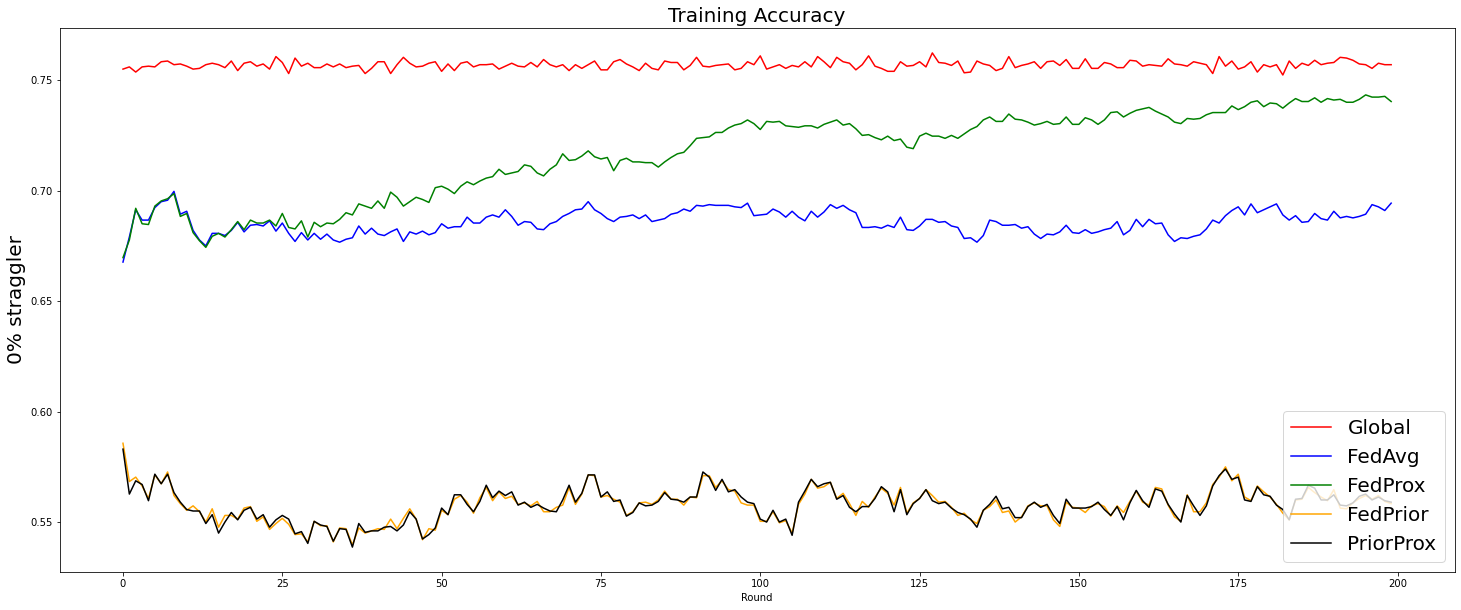

In [13]:
plt.figure(figsize=(25,10))
plt.plot(global_train,color='red')
plt.plot(avg_train,color='blue')
plt.plot(prox_train,color='green')
plt.plot(prior_train,color='orange')
plt.plot(pp_train,color='black')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

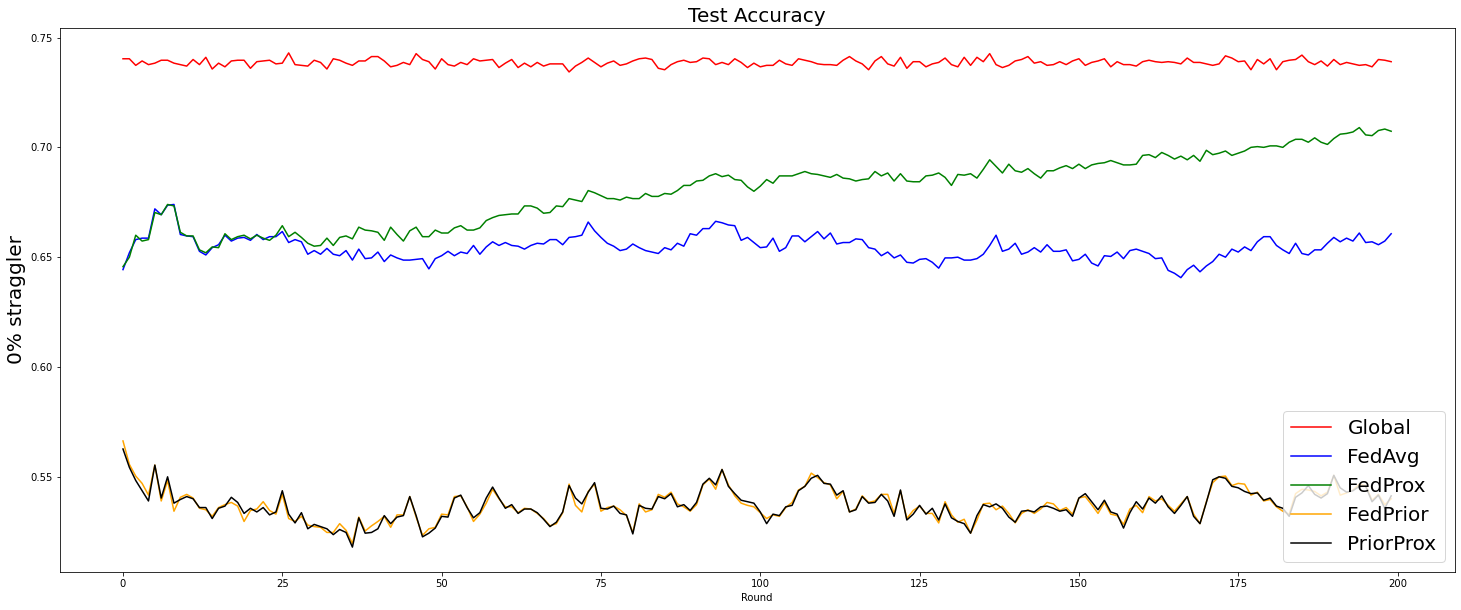

In [14]:
plt.figure(figsize=(25,10))
plt.plot(global_test,color='red')
plt.plot(avg_test,color='blue')
plt.plot(prox_test,color='green')
plt.plot(prior_test,color='orange')
plt.plot(pp_test,color='black')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Test Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

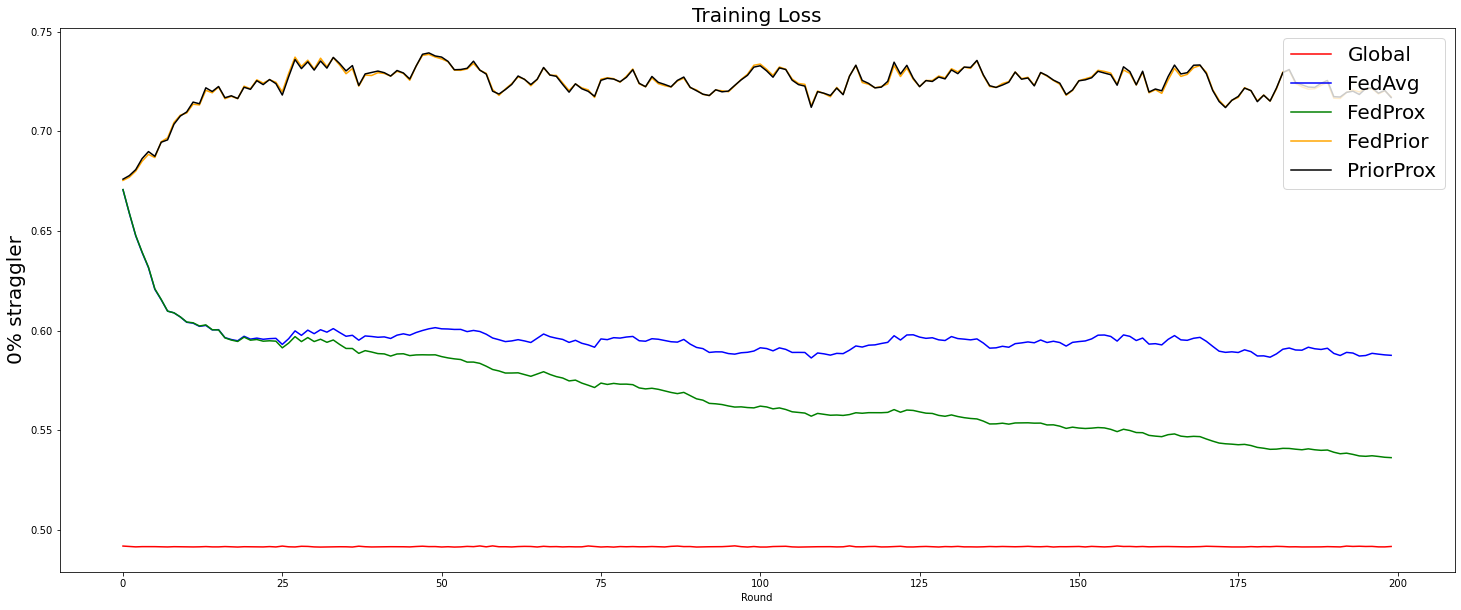

In [15]:
plt.figure(figsize=(25,10))
plt.plot(np.squeeze(loss0),color='red')
plt.plot(np.squeeze(loss1),color='blue')
plt.plot(np.squeeze(loss2),color='green')
plt.plot(np.squeeze(loss3),color='orange')
plt.plot(np.squeeze(loss4),color='black')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)

## 50% stragglers

In [16]:
straggler_rate=0.5
avg_w_5,avg_train_5,avg_test_5,loss1_5=FedAvg(rounds,client_list,dim,batchsize)
prox_w_5,prox_train_5,prox_test_5,loss2_5=FedProx(rounds,client_list,dim,batchsize)
prior_w_5,prior_train_5,prior_test_5,loss3_5=FedPrior(rounds,client_list,dim,0.1,batchsize)
pp_w_5,pp_train_5,pp_test_5,loss4_5=PriorProx(rounds,client_list,dim,0.1,batchsize)

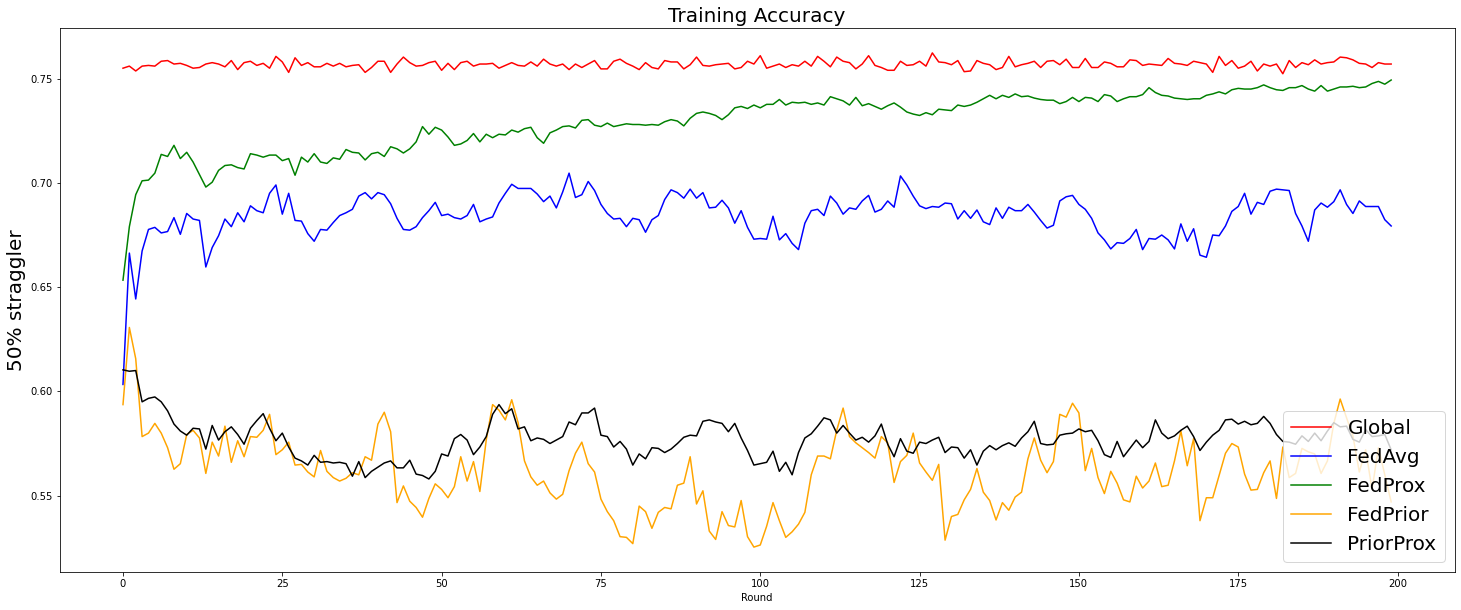

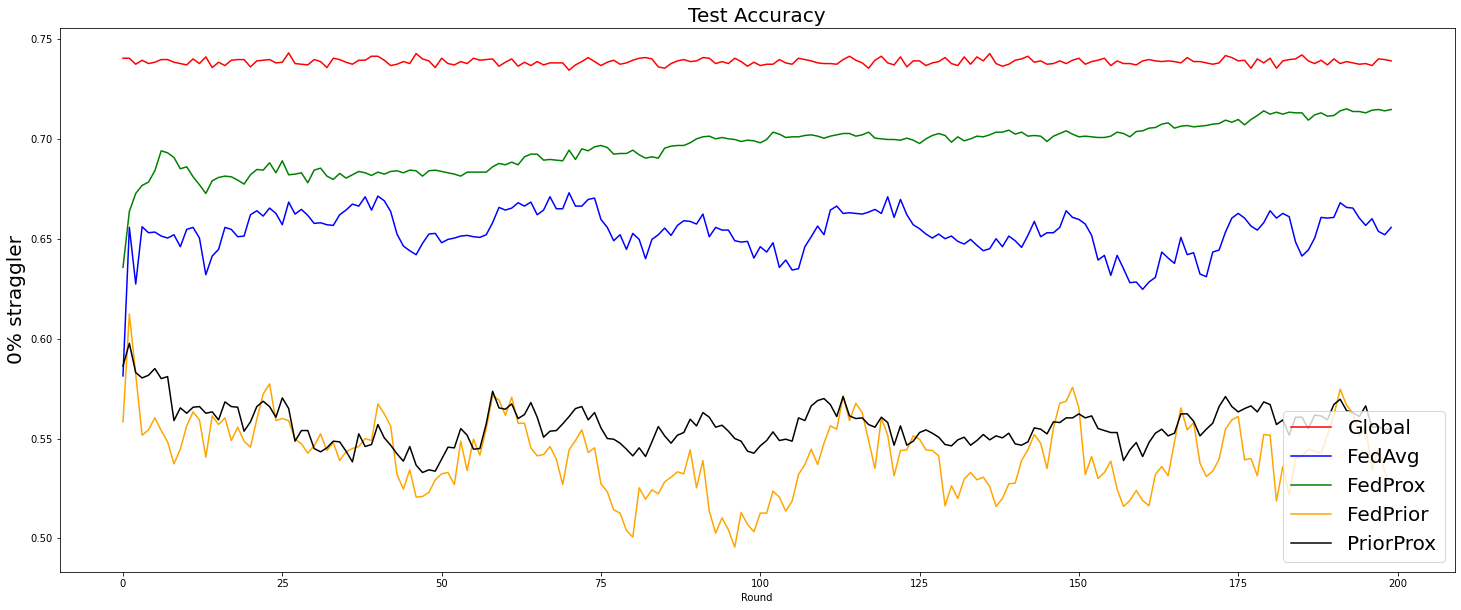

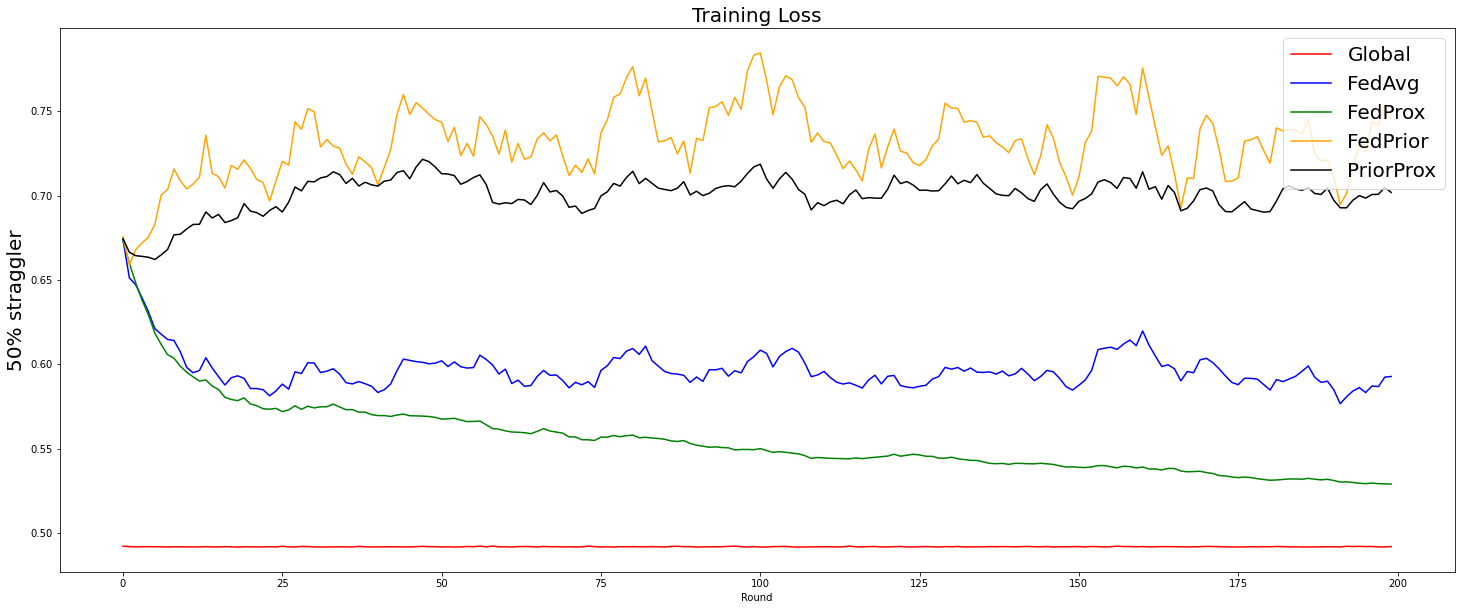

In [17]:
plt.figure(figsize=(25,10))
plt.plot(global_train,color='red')
plt.plot(avg_train_5,color='blue')
plt.plot(prox_train_5,color='green')
plt.plot(prior_train_5,color='orange')
plt.plot(pp_train_5,color='black')
plt.xlabel('Round')
plt.ylabel('50% straggler',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))
plt.plot(global_test,color='red')
plt.plot(avg_test_5,color='blue')
plt.plot(prox_test_5,color='green')
plt.plot(prior_test_5,color='orange')
plt.plot(pp_test_5,color='black')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Test Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))
#plt.ylim((-0.1,50))
plt.plot(np.squeeze(loss0),color='red')
plt.plot(np.squeeze(loss1_5),color='blue')
plt.plot(np.squeeze(loss2_5),color='green')
plt.plot(np.squeeze(loss3_5),color='orange')
plt.plot(np.squeeze(loss4_5),color='black')
plt.xlabel('Round')
plt.ylabel('50% straggler',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)

## 90% stragglers

In [18]:
straggler_rate=0.9
avg_w_9,avg_train_9,avg_test_9,loss1_9=FedAvg(rounds,client_list,dim,batchsize)
prox_w_9,prox_train_9,prox_test_9,loss2_9=FedProx(rounds,client_list,dim,batchsize)
prior_w_9,prior_train_9,prior_test_9,loss3_9=FedPrior(rounds,client_list,dim,0.1,batchsize)
pp_w_9,pp_train_9,pp_test_9,loss4_9=PriorProx(rounds,client_list,dim,0.1,batchsize)

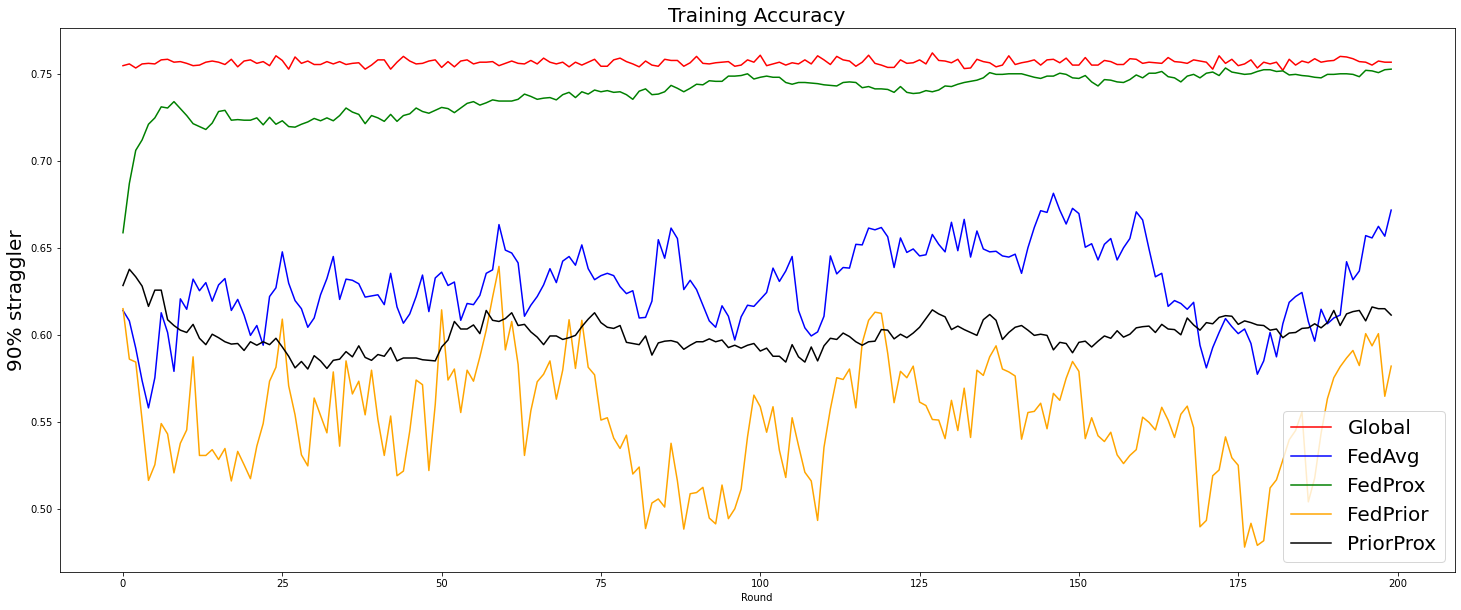

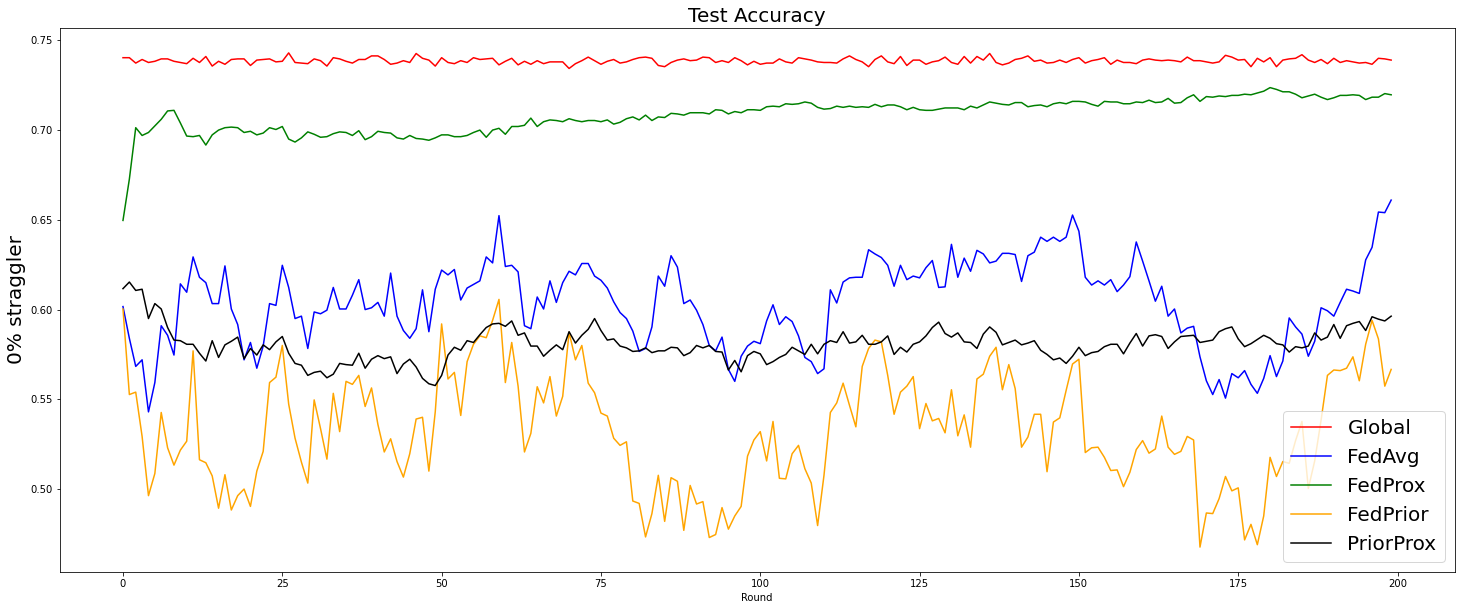

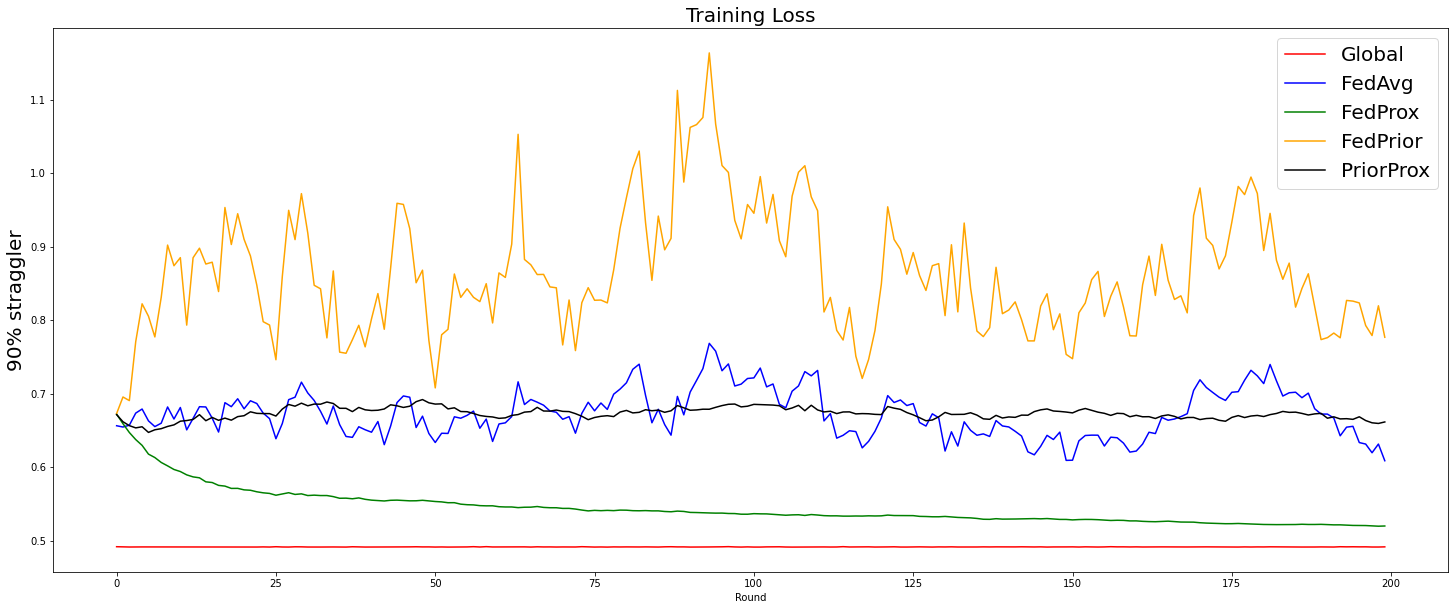

In [19]:
plt.figure(figsize=(25,10))
plt.plot(global_train,color='red')
plt.plot(avg_train_9,color='blue')
plt.plot(prox_train_9,color='green')
plt.plot(prior_train_9,color='orange')
plt.plot(pp_train_9,color='black')
plt.xlabel('Round')
plt.ylabel('90% straggler',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))
plt.plot(global_test,color='red')
plt.plot(avg_test_9,color='blue')
plt.plot(prox_test_9,color='green')
plt.plot(prior_test_9,color='orange')
plt.plot(pp_test_9,color='black')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Test Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))

plt.plot(np.squeeze(loss0),color='red')
plt.plot(np.squeeze(loss1_9),color='blue')
plt.plot(np.squeeze(loss2_9),color='green')
plt.plot(np.squeeze(loss3_9),color='orange')
plt.plot(np.squeeze(loss4_9),color='black')
plt.xlabel('Round')
plt.ylabel('90% straggler',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)

# Figure2

## iid

In [11]:

straggler_rate=0.5

#产生数据
alpha=1
beta=1
np.random.seed(666)#固定wk
wk=create_wk(alpha,dim)
cov_1=np.identity(dim)
Bk=np.squeeze(np.random.normal(loc =0 , scale= beta,size = (1,dim)))
vk=np.squeeze(np.random.multivariate_normal(Bk, cov_1, (1,), 'raise'))
    
client_list=[]
for i in range(0,clients_num):
    np.random.seed(i)
    x1,y1=iid(wk,beta,dim,num,vk)
    client1=Client(x1[0:num],y1[0:num])
    client_list.append(client1)
    if i<1:
        test_x=x1[num:]
        test_y=y1[num:]
        x_global=x1[0:num]
        y_global=y1[0:num]
    elif i>=1:
        test_x=np.vstack((test_x,x1[num:]))
        test_y=np.vstack((test_y,y1[num:]))
        x_global=np.vstack((x_global,x1[0:num]))
        y_global=np.vstack((y_global,y1[0:num]))

global_w_iid,global_train_iid,global_test_iid,loss0_iid=Global(rounds,x_global,y_global,batchsize)
avg_w_iid,avg_train_iid,avg_test_iid,loss1_iid=FedAvg(rounds,client_list,dim,batchsize)
prox_w_iid,prox_train_iid,prox_test_iid,loss2_iid=FedProx(rounds,client_list,dim,batchsize)
prior_w_iid,prior_train_iid,prior_test_iid,loss3_iid=FedPrior(rounds,client_list,dim,0.1,batchsize)
pp_w_iid,pp_train_iid,pp_test_iid,loss4_iid=PriorProx(rounds,client_list,dim,0.1,batchsize)


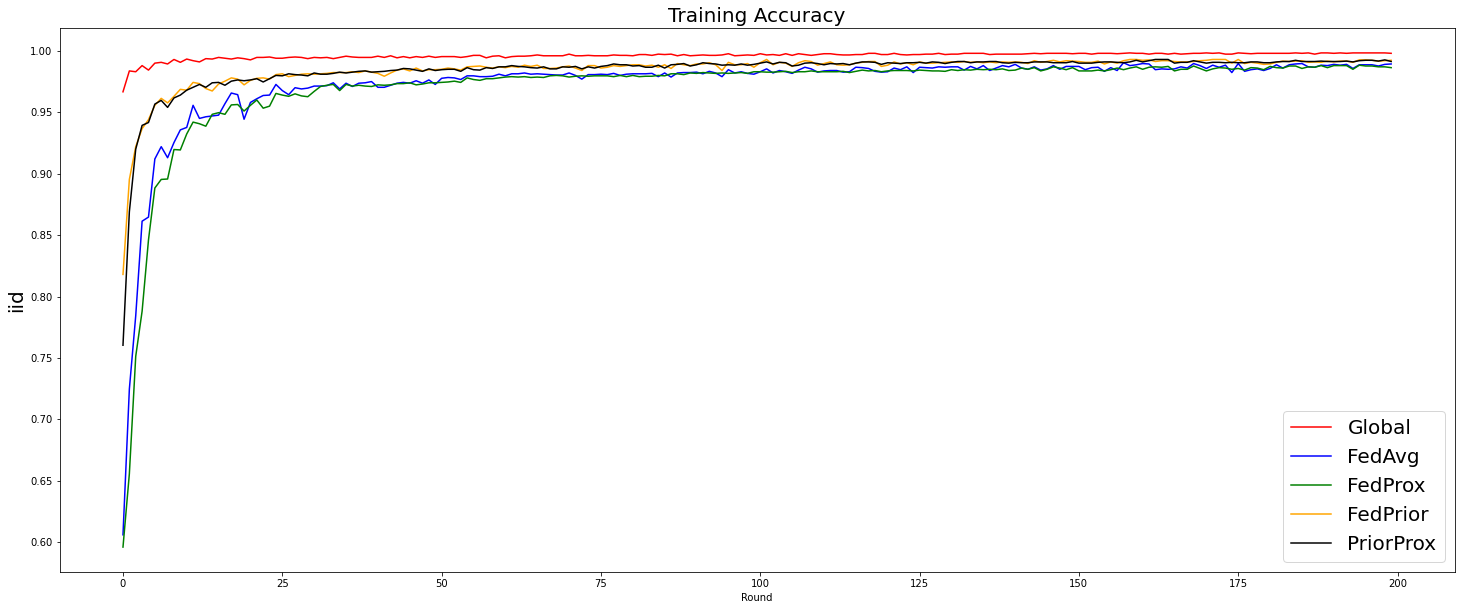

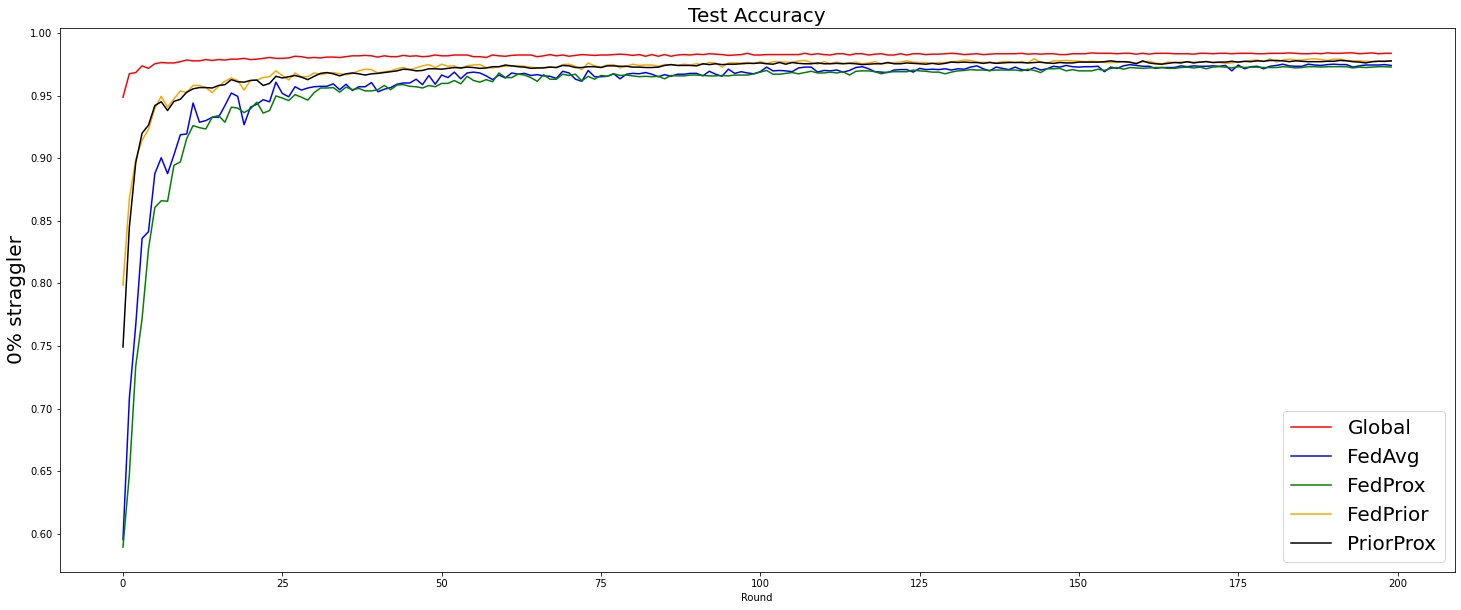

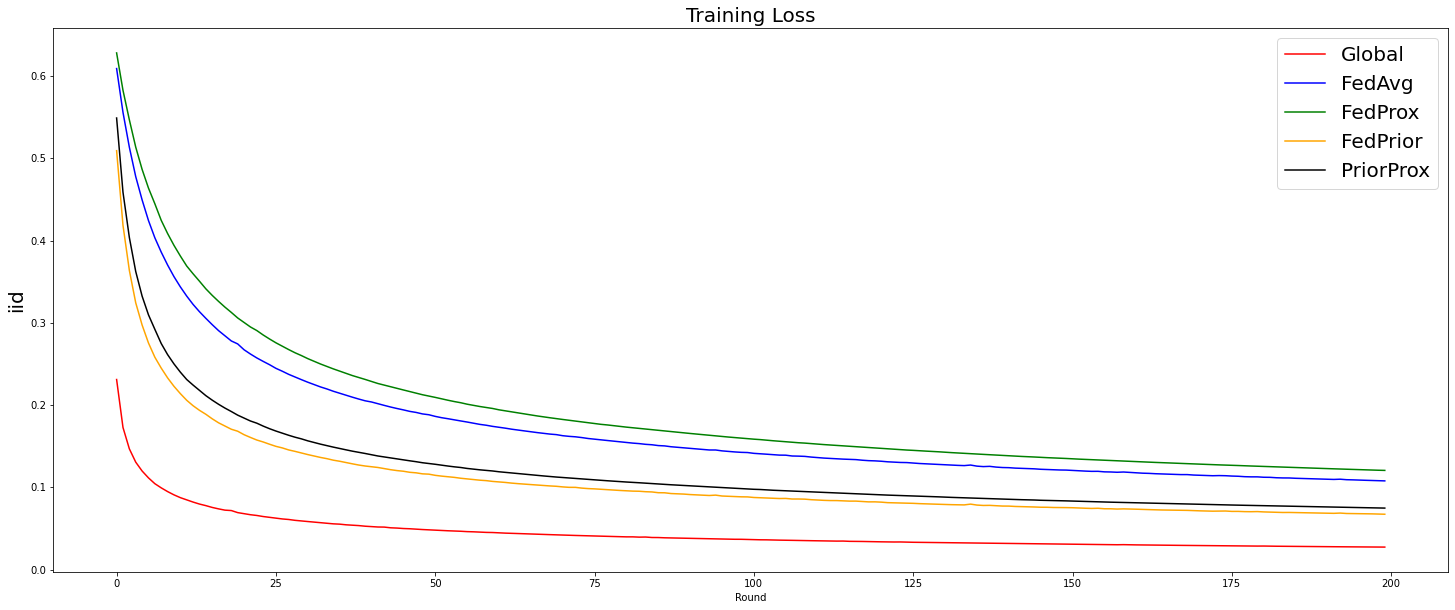

In [12]:
plt.figure(figsize=(25,10))
plt.plot(global_train_iid,color='red')
plt.plot(avg_train_iid,color='blue')
plt.plot(prox_train_iid,color='green')
plt.plot(prior_train_iid,color='orange')
plt.plot(pp_train_iid,color='black')
plt.xlabel('Round')
plt.ylabel('iid',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))
plt.plot(global_test_iid,color='red')
plt.plot(avg_test_iid,color='blue')
plt.plot(prox_test_iid,color='green')
plt.plot(prior_test_iid,color='orange')
plt.plot(pp_test_iid,color='black')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Test Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))

plt.plot(np.squeeze(loss0_iid),color='red')
plt.plot(np.squeeze(loss1_iid),color='blue')
plt.plot(np.squeeze(loss2_iid),color='green')
plt.plot(np.squeeze(loss3_iid),color='orange')
plt.plot(np.squeeze(loss4_iid),color='black')
plt.xlabel('Round')
plt.ylabel('iid',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)

## sythetic(0.5,0.5)

In [13]:

beta=0.5
alpha=0.5


#产生数据
client_list=[]
for i in range(0,clients_num):
    np.random.seed(i)
    x1,y1=multdata(alpha,beta,dim,num)
    client1=Client(x1[0:num],y1[0:num])
    client_list.append(client1)
    if i<1:
        test_x=x1[num:]
        test_y=y1[num:]
        x_global=x1[0:num]
        y_global=y1[0:num]
    elif i>=1:
        test_x=np.vstack((test_x,x1[num:]))
        test_y=np.vstack((test_y,y1[num:]))
        x_global=np.vstack((x_global,x1[0:num]))
        y_global=np.vstack((y_global,y1[0:num]))

global_w_0505,global_train_0505,global_test_0505,loss0_0505=Global(rounds,x_global,y_global,batchsize)
avg_w_0505,avg_train_0505,avg_test_0505,loss1_0505=FedAvg(rounds,client_list,dim,batchsize)
prox_w_0505,prox_train_0505,prox_test_0505,loss2_0505=FedProx(rounds,client_list,dim,batchsize)
prior_w_0505,prior_train_0505,prior_test_0505,loss3_0505=FedPrior(rounds,client_list,dim,0.1,batchsize)
pp_w_0505,pp_train_0505,pp_test_0505,loss4_0505=PriorProx(rounds,client_list,dim,0.1,batchsize)

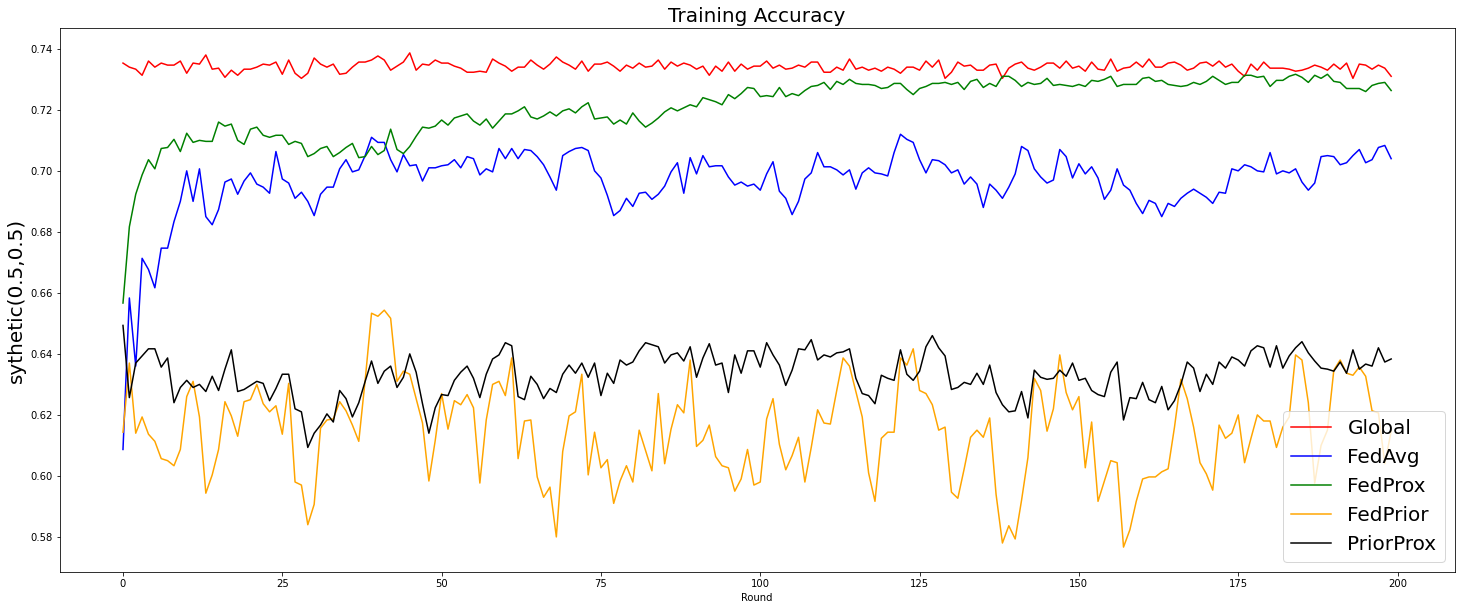

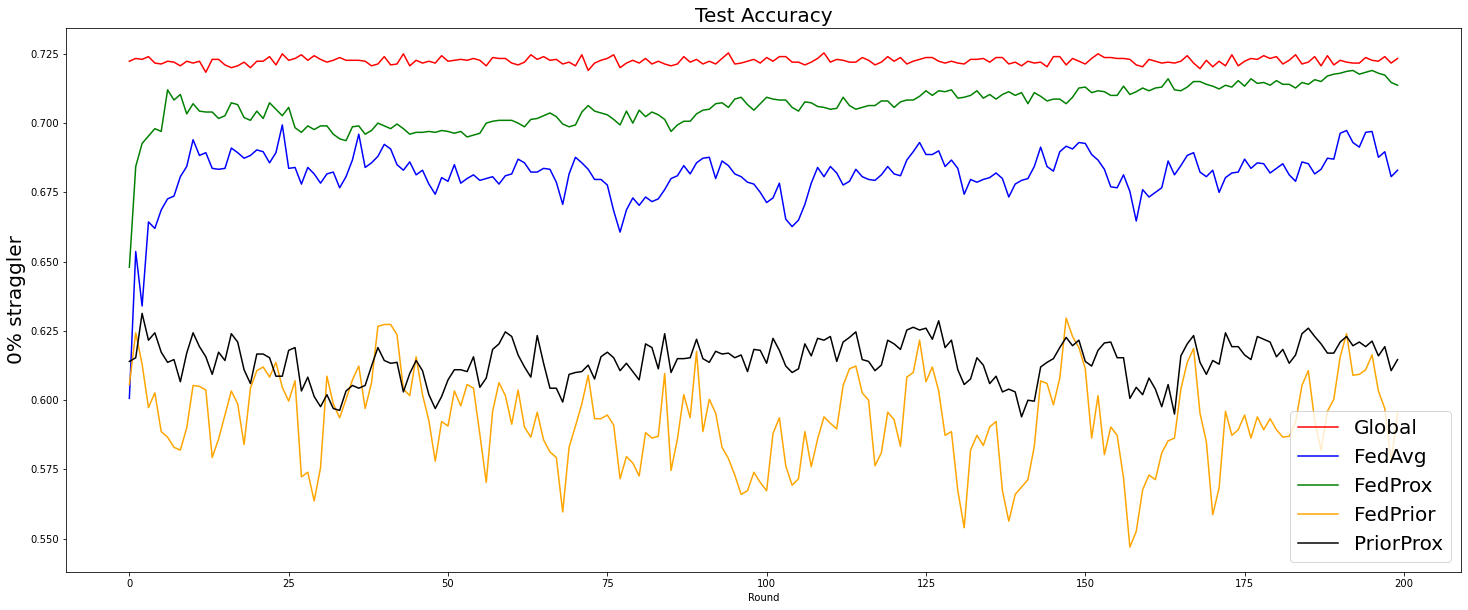

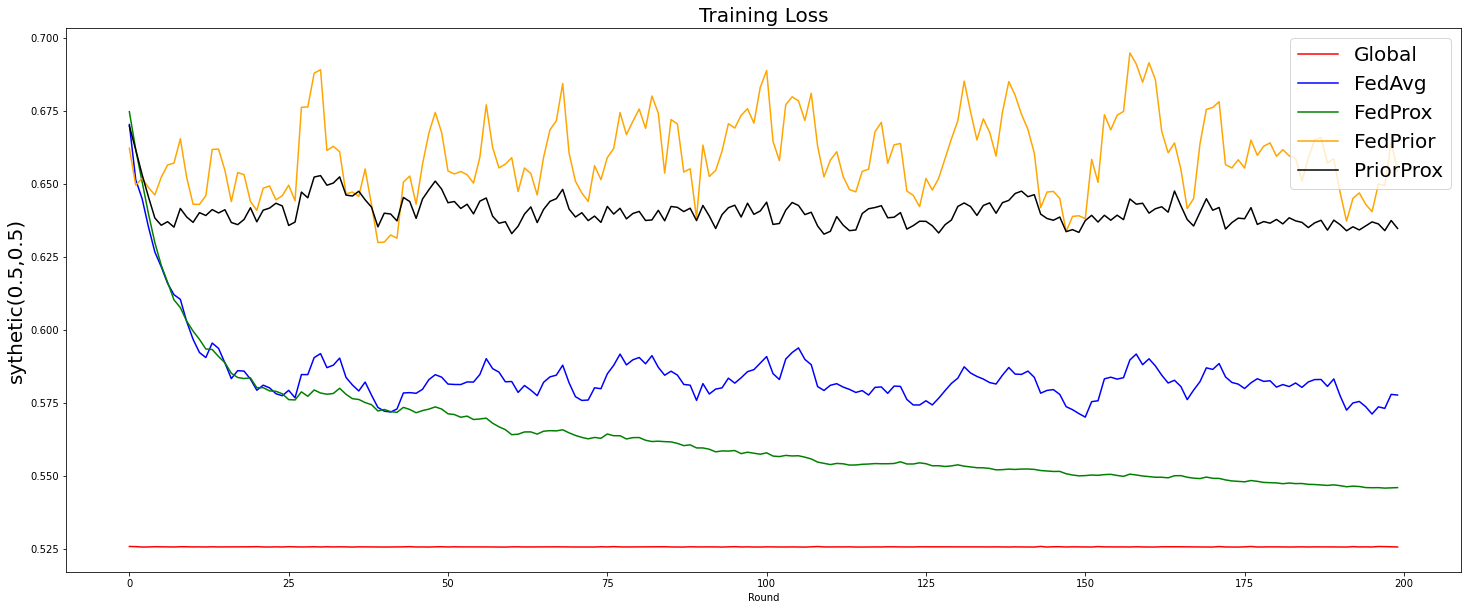

In [14]:
plt.figure(figsize=(25,10))
plt.plot(global_train_0505,color='red')
plt.plot(avg_train_0505,color='blue')
plt.plot(prox_train_0505,color='green')
plt.plot(prior_train_0505,color='orange')
plt.plot(pp_train_0505,color='black')
plt.xlabel('Round')
plt.ylabel('sythetic(0.5,0.5)',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)
plt.show()

plt.figure(figsize=(25,10))
plt.plot(global_test_0505,color='red')
plt.plot(avg_test_0505,color='blue')
plt.plot(prox_test_0505,color='green')
plt.plot(prior_test_0505,color='orange')
plt.plot(pp_test_0505,color='black')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Test Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))
#plt.ylim((-0.1,0.5))
plt.plot(np.squeeze(loss0_0505),color='red')
plt.plot(np.squeeze(loss1_0505),color='blue')
plt.plot(np.squeeze(loss2_0505),color='green')
plt.plot(np.squeeze(loss3_0505),color='orange')
plt.plot(np.squeeze(loss4_0505),color='black')
plt.xlabel('Round')
plt.ylabel('sythetic(0.5,0.5)',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)
plt.show()

In [ ]:
#logistic版本
##n<p
##步长减小

#softmax
##步长
##test很小？